In [ ]:
import pandas

In [ ]:
dataframe = pandas.read_csv("pythonstatisticsdataset.csv")

In [ ]:
table = pandas.DataFrame(dataframe)

In [ ]:
#Descriptive Statistics showing average, count of values, standard deviation, min, max for basic understanding of numerical data
table.describe()

,order_id,unit_price,quantity,total_sales
count,50.00000,50.000000,50.000000,50.000000
mean,1025.50000,3577.000000,2.060000,4345.940000
std,14.57738,5266.152606,1.268295,5093.754813
min,1001.00000,199.000000,1.000000,597.000000
25%,1013.25000,499.000000,1.000000,1299.000000
50%,1025.50000,1399.000000,2.000000,1998.000000
75%,1037.75000,4749.000000,3.000000,5373.750000
max,1050.00000,18999.000000,6.000000,18999.000000


In [ ]:
#used to describe the columns available and first 5 sample rows
table.head()

,order_id,order_date,region,customer_id,product_name,category,unit_price,quantity,total_sales
0,1001,2025-01-01,South,C101,Wireless Mouse,Electronics,799,2,1598
1,1002,2025-01-02,West,C102,Office Chair,Furniture,5499,1,5499
2,1003,2025-01-03,North,C103,Water Bottle,Accessories,299,3,897
3,1004,2025-01-04,East,C104,Laptop Stand,Electronics,1299,2,2598
4,1005,2025-01-05,South,C105,Notebook Pack,Stationery,499,4,1996


In [ ]:
#shows the type of object, number of rows and columns, data type and count of rows, memory usage
table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   order_id      50 non-null     int64 
 1   order_date    50 non-null     object
 2   region        50 non-null     object
 3   customer_id   50 non-null     object
 4   product_name  50 non-null     object
 5   category      50 non-null     object
 6   unit_price    50 non-null     int64 
 7   quantity      50 non-null     int64 
 8   total_sales   50 non-null     int64 
dtypes: int64(4), object(5)
memory usage: 3.6+ KB


In [ ]:
#correlation between two or more variables to show how increase in one variable affects another variable.
table[['unit_price','quantity','total_sales']].corr()

,unit_price,quantity,total_sales
unit_price,1.000000,-0.461798,0.980032
quantity,-0.461798,1.000000,-0.388310
total_sales,0.980032,-0.388310,1.000000


In [ ]:
#grouping region column by sum of total sales column
table.groupby('region')['total_sales'].sum()

,total_sales
region,
East,40783
North,39068
South,39875
West,97571


In [ ]:
#grouping category column by sum of total sales column
table.groupby('category')['total_sales'].sum()

,total_sales
category,
Accessories,4186
Bags,10493
Electronics,137569
Furniture,52485
Stationery,12564


<Axes: xlabel='order_date'>

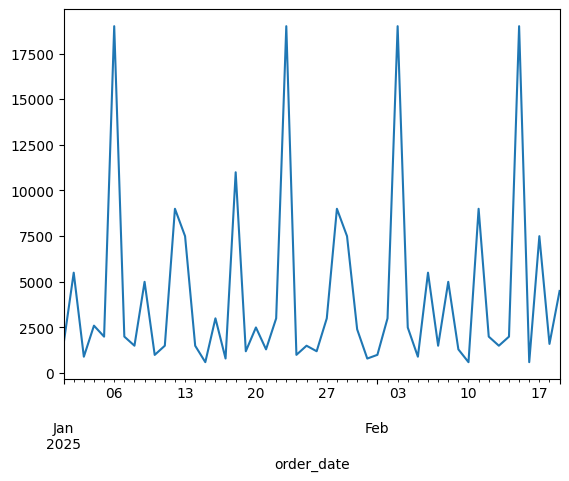

In [ ]:
#trend analysis using grouping of order date column by sum of total sales and creating line chart
table['order_date'] = pandas.to_datetime(table['order_date'])
table.groupby('order_date')['total_sales'].sum().plot()

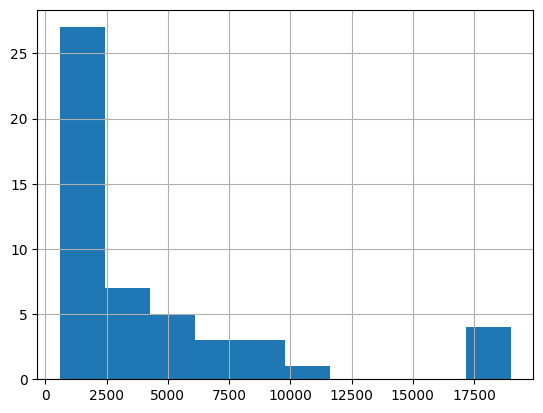

In [ ]:
#distribution using histogram to see most common value in a column and most least values in a column
import matplotlib.pyplot as plt
table['total_sales'].hist()
plt.show()

In [ ]:
#skew distribution method to check whether most data are small or big
table['total_sales'].skew()

np.float64(2.002699708975611)

In [ ]:
#kurtosis distribution method to check whether the date has less or more outliers
table['total_sales'].kurt()

np.float64(3.3415313009629246)

In [ ]:
#sorting the total sales descending order by group of product name to check largest sales values
table.groupby('product_name')['total_sales'].sum().sort_values(ascending=False)

,total_sales
product_name,
Smartphone,75996
Monitor,26997
Office Desk,22497
Office Chair,21996
Bluetooth Speaker,12495
Keyboard,10493
Backpack,10493
Notebook Pack,8982
Desk Lamp,7992


In [ ]:
#hypothesis testing to check significant difference pvalue and statistic difference
from scipy import stats

#filtering total sales by region and creating new variables
south = table[table['region']=='South']['total_sales']
west = table[table['region']=='West']['total_sales']

#Compare sales between two regions
stats.ttest_ind(south, west)

TtestResult(statistic=np.float64(-2.0996877859829874), pvalue=np.float64(0.04645144173191395), df=np.float64(24.0))

In [ ]:
#linear regression to predict if one variable affects another
#coefficient will check how much y variable change if x variable changes by 1 value

from sklearn.linear_model import LinearRegression

X = table[['unit_price']]
y = table['quantity']

model = LinearRegression()
model.fit(X, y)

model.coef_

array([-0.00011122])

<Axes: >

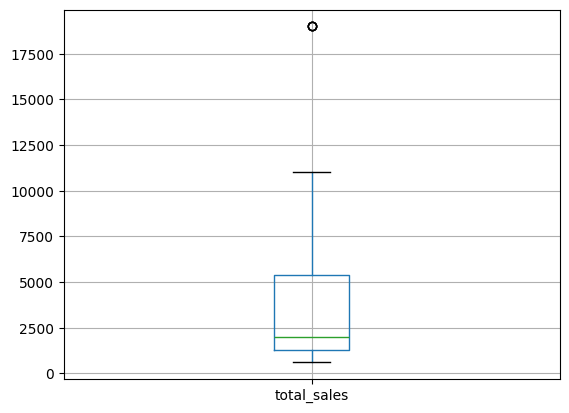

In [ ]:
#outlier detection using box plot graph
table.boxplot(column='total_sales')

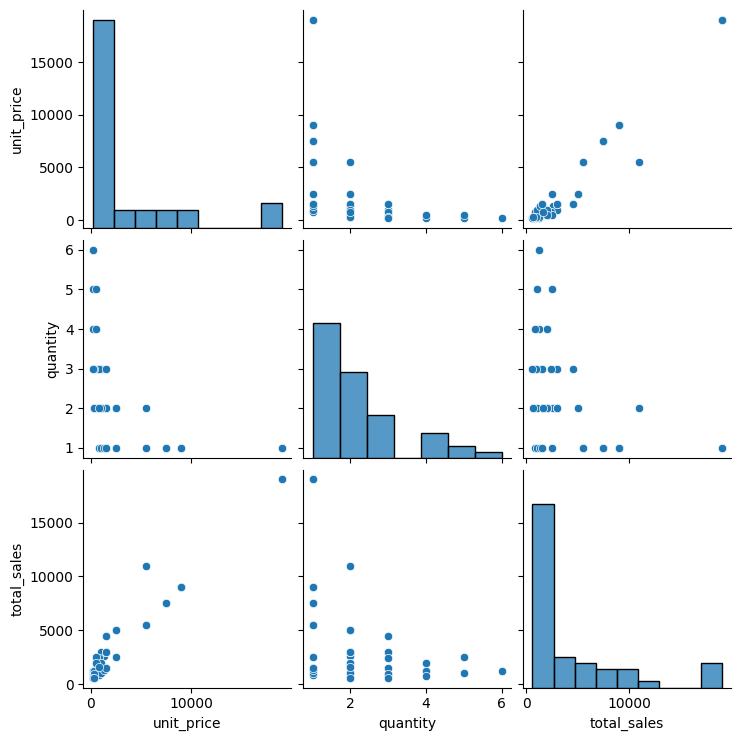

In [ ]:
#feature relationships using pair plot to check relationship between each variables separately
import seaborn
seaborn.pairplot(table[['unit_price','quantity','total_sales']])